# K-Means Clustering  
K-Means clustering merupakan salah satu metode dalam unsupervised learning yang digunakan untuk mengelompokkan data ke dalam beberapa kelompok (cluster) berdasarkan kesamaan karakteristik atau fitur. Tujuan utamanya adalah untuk membagi data ke dalam K kelompok yang saling terpisah, dimana dalam kelompok data bersifat homogen dan antar kelompok data bersifat heterogen.  

## Langkah-langkah algoritma K-Means :  
1. Menentukan jumlah kluster sebanyak $K$  
* Artinya menentukan berapa banyak kelompok/kluster yang ingin dibuat dari data. Misalnya $K$ = 3 maka membagi data menjadi 3 kluster. 
* Pemilihan nilai $K$ dapat menggunakan metode seperti Elbow Method untuk membantu menentukan $K$ yang optimal.   
2. Memilih K centroid awal secara acak  
* Artinya menentukan titik awal (centroid) sebagai pusat dari masing-masing kluster.  
* Centroid bisa dipilih secara acak dari data yang ada atau menggunakan teknik seperti K-Means++ dimana dijalankan secara otomatis pada scikit-learn untuk hasil centroid yang lebih baik.  
3. Menghitung jarak setiap data ke tiap centroid  
* Artinya menentukan seberapa dekat setiap data ke setiap centroid.
* Umumnya menggunakan Euclidian distance.
4. Mengelompokkan data berdasarkan centroid terdekat  
* Artinya mengklasifikasikan setiap data ke dalam salah satu dari $K$ kluster.  
* Setiap data ditempatkan ke kluster yang pusatnya (centroid-nya) paling dekat dengannya. Jadi, tiap data hanya masuk ke satu kluster. 
5. Menghitung rata-rata dari anggota kluster, untuk menemukan centroid baru
* Menentukan pusat kluster baru berdasarkan data yang saat ini berada dalam kluster tersebut.  
* Centroid baru adalah rata-rata dari semua data di dalam suatu kluster. 
6. Mengulang langkah nomor 3-5 sampai data pada setiap kluster tidak berubah signifikan.  
* Iterasi dilakukan sampai tidak ada lagi data yang berpindah kluster, atau perubahan posisi centroid sangat kecil.  

## Evaluasi Hasil K-Means  
1. Inertia (Sum Square Error/SSE)  
Inertia mengukur sejauh mana titik data dalam suatu cluster tersebar dari pusat cluster tersebut. Semakin kecil nilai inertia, klaster semakin baik.  

$$Inertia= \sum_{i=1}^{n} \left\| x_i - \mu_{c_i} \right\|^2$$  

**Keterangan** :   
$x_i$ : Titik data ke-$i$  
$\mu_{c_i}$ : Centroid dari cluster tempat $x_i$ berada  

* Nilai inertia (sangat kecil/mendekati 0) : Klaster sangat kompak dan semua titik dekat dengan centroidnya (**sangat baik**).  
* Nilai inertia (kecil-sedang) : Klaster cukup baik dan dapat diterima dalam banyak kasus.  
* Nilai inertia (besar) : Klaster tidak rapat,  data menyebar jauh dari centroid → bisa jadi jumlah klaster (k) kurang tepat atau K-Means tidak cocok digunakan.



2. Silhouette Method : Sebuah metode yang mengukur tingkat kemiripan suatu point dengan clusternya dibandingkan dengan kluster lain.  

* untuk setiap titik $i$, silhouette ($i$) dihitung sebagai :   

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$  

**Keterangan** :  
$a(i)$ : rata-rata jarak titik $i$ ke semua titik lain dalam klaster yang sama.  
$b(i)$ : rata-rata jarak titik $i$ ke semua titik dalam klaster terdekat (tetangga).

* Nilai silhouette mendekati angka 1 artinya suatu data berada pada cluster yang benar dengan jarak jauh dari cluster lain. 
* Nilai silhouette negatif artinya data tersebut lebih baik berada di kluster lain daripada kluster saat ini.
* Nilai silhouette = 0, artinya data tersebut di perbatasan antara dua cluster.  



## Komputasi K-Means Data IRIS

### Perhitungan Manual tanpa library sklearn

Konvergen pada iterasi ke-7
   sepal_length  sepal_width  petal_length  petal_width  cluster
0           5.1          3.5           1.4          0.2        1
1           4.9          3.0           1.4          0.2        1
2           4.7          3.2           1.3          0.2        1
3           4.6          3.1           1.5          0.2        1
4           5.0          3.6           1.4          0.2        1


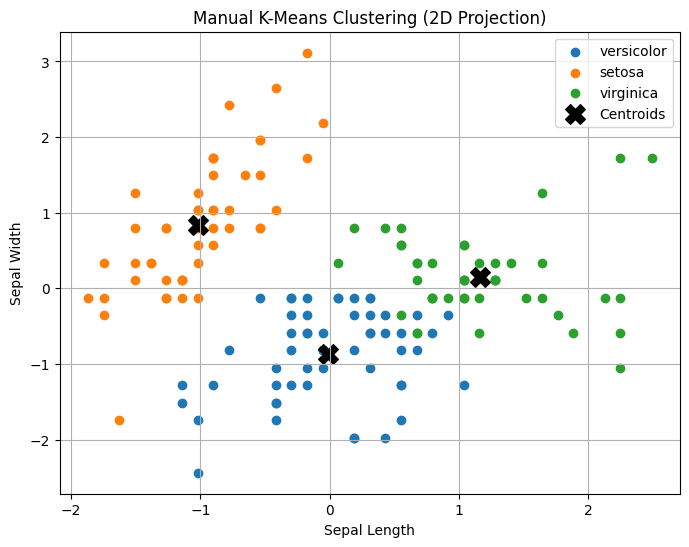

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load data (contoh dari file iris atau buat sendiri) ===
data = pd.read_excel("data_iris.xlsx")
X = data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

# === 2. Standarisasi (optional, tapi disarankan) ===
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 3. Tentukan K dan inisialisasi centroid secara acak ===
K = 3
np.random.seed(42)
initial_indices = np.random.choice(len(X_scaled), K, replace=False)
centroids = X_scaled[initial_indices]

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# === 4. Iterasi K-Means manual ===
max_iter = 100
for iteration in range(max_iter):
    # a. Hitung jarak setiap titik ke tiap centroid
    distances = np.array([[euclidean_distance(x, c) for c in centroids] for x in X_scaled])

    # b. Assign kluster berdasarkan jarak minimum
    cluster_labels = np.argmin(distances, axis=1)

    # c. Hitung centroid baru
    new_centroids = np.array([X_scaled[cluster_labels == k].mean(axis=0) for k in range(K)])

    # d. Cek konvergensi (jika centroid tidak berubah signifikan)
    if np.allclose(centroids, new_centroids):
        print(f"Konvergen pada iterasi ke-{iteration+1}")
        break

    centroids = new_centroids

# === 5. Tampilkan hasil klustering ===
cluster_spesies = {
    0: 'versicolor',
    1: 'setosa',
    2: 'virginica'
}

data['cluster'] = cluster_labels
print(data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'cluster']].head())

# (Opsional) === 6. Visualisasi 2D (pakai 2 fitur) ===
plt.figure(figsize=(8, 6))
for k in range(K):
    cluster_points = X_scaled[cluster_labels == k]
    label = cluster_spesies [k]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label= label)
plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=200, label='Centroids')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.title("Manual K-Means Clustering (2D Projection)")
plt.grid(True)
plt.show()


### K-Means clustering dengan library sklearn

### K = 2 ( 2 Kluster )  

Jumlah iterasi: 7
   id  petal_length  petal_width  sepal_length  sepal_width  cluster
0   1           1.4          0.2           5.1          3.5        1
1   2           1.4          0.2           4.9          3.0        1
2   3           1.3          0.2           4.7          3.2        1
3   4           1.5          0.2           4.6          3.1        1
4   5           1.4          0.2           5.0          3.6        1
Inertia (total within-cluster sum of squares): 223.73200573676343
Silhouette Score: 0.580184463257396


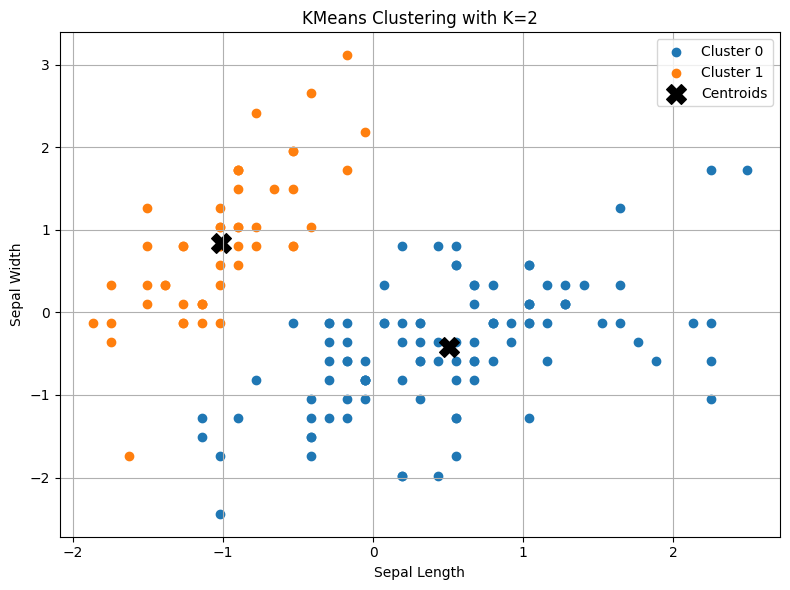

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Ambil fitur
features = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# Standarisasi
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Tentukan jumlah klaster
K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

# Fit model
kmeans.fit(scaled_features)

# Tambahkan hasil kluster ke DataFrame
df['cluster'] = kmeans.labels_

# Tampilkan hasil
print("Jumlah iterasi:", kmeans.n_iter_)
print(df.head())

# Hitung inertia
print("Inertia (total within-cluster sum of squares):", kmeans.inertia_)

# Hitung silhouette score
sil_score = silhouette_score(scaled_features, kmeans.labels_)
print("Silhouette Score:", sil_score)

# Visualisasi menggunakan dua fitur pertama (misalnya: sepal_length dan sepal_width)
plt.figure(figsize=(8, 6))
for cluster_id in range(K):
    cluster_points = scaled_features[df['cluster'] == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id}')

# Centroid (dalam bentuk yang sudah diskalakan)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title(f'KMeans Clustering with K={K}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### K = 3 ( 3 Kluster)

Jumlah iterasi: 4
   id  petal_length  petal_width  sepal_length  sepal_width  cluster
0   1           1.4          0.2           5.1          3.5        1
1   2           1.4          0.2           4.9          3.0        1
2   3           1.3          0.2           4.7          3.2        1
3   4           1.5          0.2           4.6          3.1        1
4   5           1.4          0.2           5.0          3.6        1
Inertia (total within-cluster sum of squares): 140.96581663074699
Silhouette Score: 0.4589717867018717


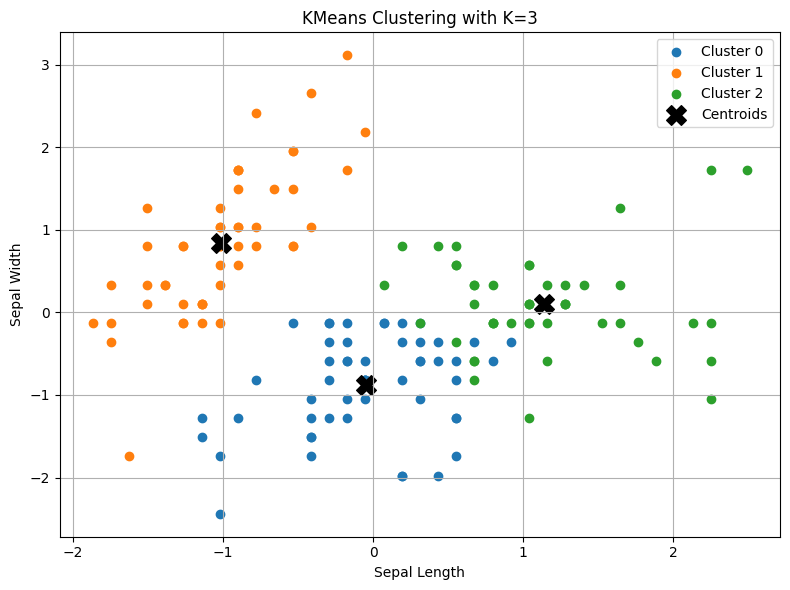

In [13]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Ambil fitur
features = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# Standarisasi
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Tentukan jumlah klaster
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

# Fit model
kmeans.fit(scaled_features)

# Tambahkan hasil kluster ke DataFrame
df['cluster'] = kmeans.labels_

# Tampilkan hasil
print("Jumlah iterasi:", kmeans.n_iter_)
print(df.head())

# Hitung inertia
print("Inertia (total within-cluster sum of squares):", kmeans.inertia_)

# Hitung silhouette score
sil_score = silhouette_score(scaled_features, kmeans.labels_)
print("Silhouette Score:", sil_score)

# Visualisasi menggunakan dua fitur pertama (misalnya: sepal_length dan sepal_width)
plt.figure(figsize=(8, 6))
for cluster_id in range(K):
    cluster_points = scaled_features[df['cluster'] == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id}')

# Centroid (dalam bentuk yang sudah diskalakan)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title(f'KMeans Clustering with K={K}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### K = 4 ( 4 Kluster)

Jumlah iterasi: 4
   id  petal_length  petal_width  sepal_length  sepal_width  cluster
0   1           1.4          0.2           5.1          3.5        2
1   2           1.4          0.2           4.9          3.0        3
2   3           1.3          0.2           4.7          3.2        3
3   4           1.5          0.2           4.6          3.1        3
4   5           1.4          0.2           5.0          3.6        2
Inertia (total within-cluster sum of squares): 114.61788585776682
Silhouette Score: 0.38528456243462456


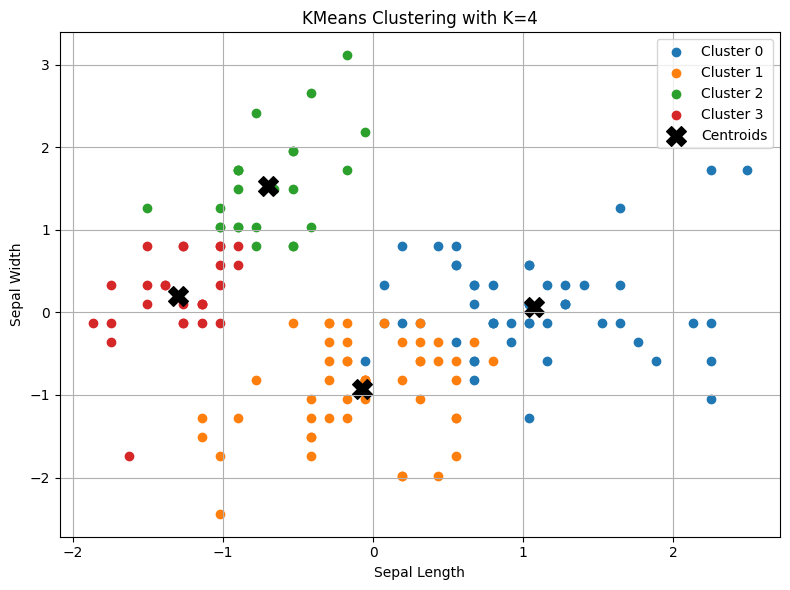

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Ambil fitur
features = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# Standarisasi
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Tentukan jumlah klaster
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)

# Fit model
kmeans.fit(scaled_features)

# Tambahkan hasil kluster ke DataFrame
df['cluster'] = kmeans.labels_

# Tampilkan hasil
print("Jumlah iterasi:", kmeans.n_iter_)
print(df.head())

# Hitung inertia
print("Inertia (total within-cluster sum of squares):", kmeans.inertia_)

# Hitung silhouette score
sil_score = silhouette_score(scaled_features, kmeans.labels_)
print("Silhouette Score:", sil_score)

# Visualisasi menggunakan dua fitur pertama (misalnya: sepal_length dan sepal_width)
plt.figure(figsize=(8, 6))
for cluster_id in range(K):
    cluster_points = scaled_features[df['cluster'] == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id}')

# Centroid (dalam bentuk yang sudah diskalakan)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title(f'KMeans Clustering with K={K}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Kesimpulan :  
1. K = 2   
Inertia Score: 223.73200573676343
Silhouette Score: 0.580184463257396  

* Nilai skor inertia lebih besar dari yang lain dan nilai skor silhouette yang diperoleh adalah yang tertinggi dibandingkan dengan K lainnya (lebih mendekati 1).

2. K = 3  
Inertia : 140.96581663074699
Silhouette Score: 0.4589717867018717  

* Nilai skor inertia turun secara signifikan dan nilai skor silhouette juga mengalami penurunan dibandingkan dengan k=2 (menjauh dari 1).

3. K =4  
Inertia : 114.61788585776682
Silhouette Score: 0.38528456243462456  

* Nilai skor inertia dan nilai skor silhouette sama-sama mengalami penurunan (semakin jauh dari 1).  

Maka berdasarkan hasil evaluasi yang telah dilakukan, nilai K = 2 merupakan jumlah klaster yang paling optimal. Hal ini ditunjukkan oleh nilai silhouette score tertinggi/paling mendekati 1 (0.580).

### Metode Elbow 
Metode Elbow untuk menentukan jumlah klaster 𝑘 yang optimal dengan memantau penurunan nilai inertia seiring bertambahnya 𝑘. Titik sebelum grafik melandai adalah titik siku (elbow point) → yaitu jumlah klaster optimal.

Contoh Elbow Method :

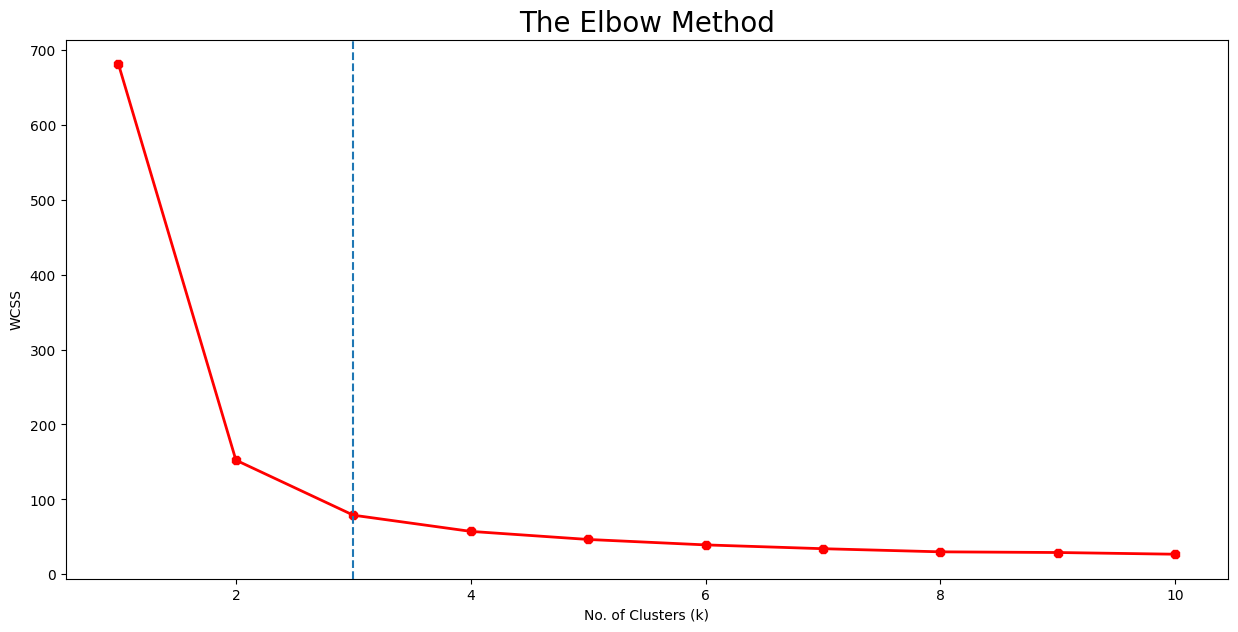

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

iris = pd.read_excel('data_iris.xlsx')
iris_x = iris.iloc[:, 1:5]
iris_x.head()

x_iris = np.array(iris_x)
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_iris)
x_scaled

wcss=[]
for i in range(1,11):
    km = KMeans(i)
    km.fit(iris_x)
    wcss.append(km.inertia_)
np.array(wcss)

fig, ax = plt.subplots(figsize=(15,7))
ax = plt.plot(range(1,11),wcss, linewidth=2, color="red", marker ="8")
plt.axvline(x=3, ls='--')
plt.ylabel('WCSS')
plt.xlabel('No. of Clusters (k)')
plt.title('The Elbow Method', fontsize = 20)
plt.show()

* Berdasarkan metode Elbow, jumlah klaster optimal adalah K = 3, karena pada titik ini terjadi penurunan WCSS (Within-Cluster Sum of Squares) yang signifikan sebelum grafik mulai melandai.